#### Loading everything from week 8

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve
%pip install xgboost
import pickle

# Load model
with open('best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

# Load test splits
X_test = pd.read_csv('X_test_cleaned.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# Load cleaned df for demographics
df_clean = pd.read_csv('nhanes_clean.csv')

# Rebuild df_test_demo
demo_cols = ['age_group', 'gender', 'ethnicity', 'education', 'poverty_ratio', 'age']
df_test_demo = df_clean.loc[X_test.index, demo_cols].copy()
df_test_demo['poverty_quartile'] = pd.qcut(df_test_demo['poverty_ratio'], q=4, 
                                            labels=['Q1 (poorest)', 'Q2', 'Q3', 'Q4 (richest)'])

# Get predictions for the full test set
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.3).astype(int)

print("Loaded successfully")
print(f"Test set: {len(y_test)} patients")

Note: you may need to restart the kernel to use updated packages.
Loaded successfully
Test set: 803 patients


#### Equalized Odds

In [7]:
# Equalized Odds by Ethnicity
groups = df_test_demo['ethnicity'].unique()
eq_odds_results = []

for group in groups:
    mask = df_test_demo['ethnicity'] == group
    y_sub = y_test[mask]
    y_pred_sub = y_pred[mask]
    
    tn, fp, fn, tp = confusion_matrix(y_sub, y_pred_sub).ravel()
    
    tpr = tp / (tp + fn)  # sensitivity — catching actual hypertensives
    fpr = fp / (fp + tn)  # false alarm rate — flagging healthy people wrongly
    
    eq_odds_results.append({
        'group': group,
        'n': mask.sum(),
        'TPR': round(tpr, 3),
        'FPR': round(fpr, 3),
    })

df_eq_odds = pd.DataFrame(eq_odds_results).sort_values('TPR')
print(df_eq_odds.to_string(index=False))

             group   n   TPR   FPR
Non-Hispanic Black 171 0.735 0.547
  Mexican American 107 0.783 0.524
Other/Multi-Racial  46 0.857 0.531
Non-Hispanic White 296 0.897 0.537
Non-Hispanic Asian 116 0.963 0.506
    Other Hispanic  67 1.000 0.457


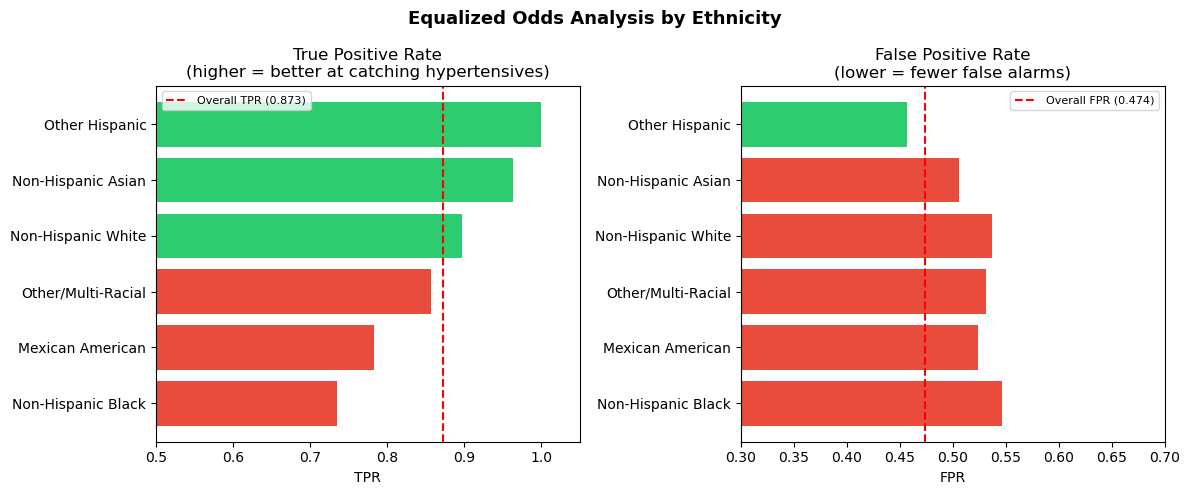

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Equalized Odds Analysis by Ethnicity', fontsize=13, fontweight='bold')

colors_tpr = ['#e74c3c' if v < 0.873 else '#2ecc71' for v in df_eq_odds['TPR']]
colors_fpr = ['#e74c3c' if v > 0.474 else '#2ecc71' for v in df_eq_odds['FPR']]

ax1.barh(df_eq_odds['group'], df_eq_odds['TPR'], color=colors_tpr)
ax1.axvline(x=0.873, color='red', linestyle='--', linewidth=1.5, label='Overall TPR (0.873)')
ax1.set_title('True Positive Rate\n(higher = better at catching hypertensives)')
ax1.set_xlim(0.5, 1.05)
ax1.legend(fontsize=8)
ax1.set_xlabel('TPR')

ax2.barh(df_eq_odds['group'], df_eq_odds['FPR'], color=colors_fpr)
ax2.axvline(x=0.474, color='red', linestyle='--', linewidth=1.5, label='Overall FPR (0.474)')
ax2.set_title('False Positive Rate\n(lower = fewer false alarms)')
ax2.set_xlim(0.3, 0.7)
ax2.legend(fontsize=8)
ax2.set_xlabel('FPR')

plt.tight_layout()
plt.savefig('week9_equalized_odds.png', dpi=150, bbox_inches='tight')
plt.show()

##### The equalized odds analysis reveals a significant TPR disparity across ethnic groups. Other Hispanic patients show the highest TPR (1.000), meaning the model catches every actual hypertensive case in that group, while Non-Hispanic Black patients show the lowest TPR (0.735) — a gap of 26.5 percentage points. This is the core equalized odds violation: the model is substantially less effective at identifying hypertension in Black patients than in Hispanic patients, which translates directly to more missed diagnoses. On the FPR side, the disparity is smaller but still present — Other Hispanic shows the lowest false alarm rate (0.457) while Non-Hispanic Black shows the highest (0.547), a 9 percentage point difference. Notably, almost all groups exceed the overall FPR benchmark, suggesting the aggressive classification threshold of 0.3 creates a model-wide tendency to over-flag healthy patients regardless of ethnicity — this is a threshold calibration issue rather than a fairness issue specifically.

#### Calibration

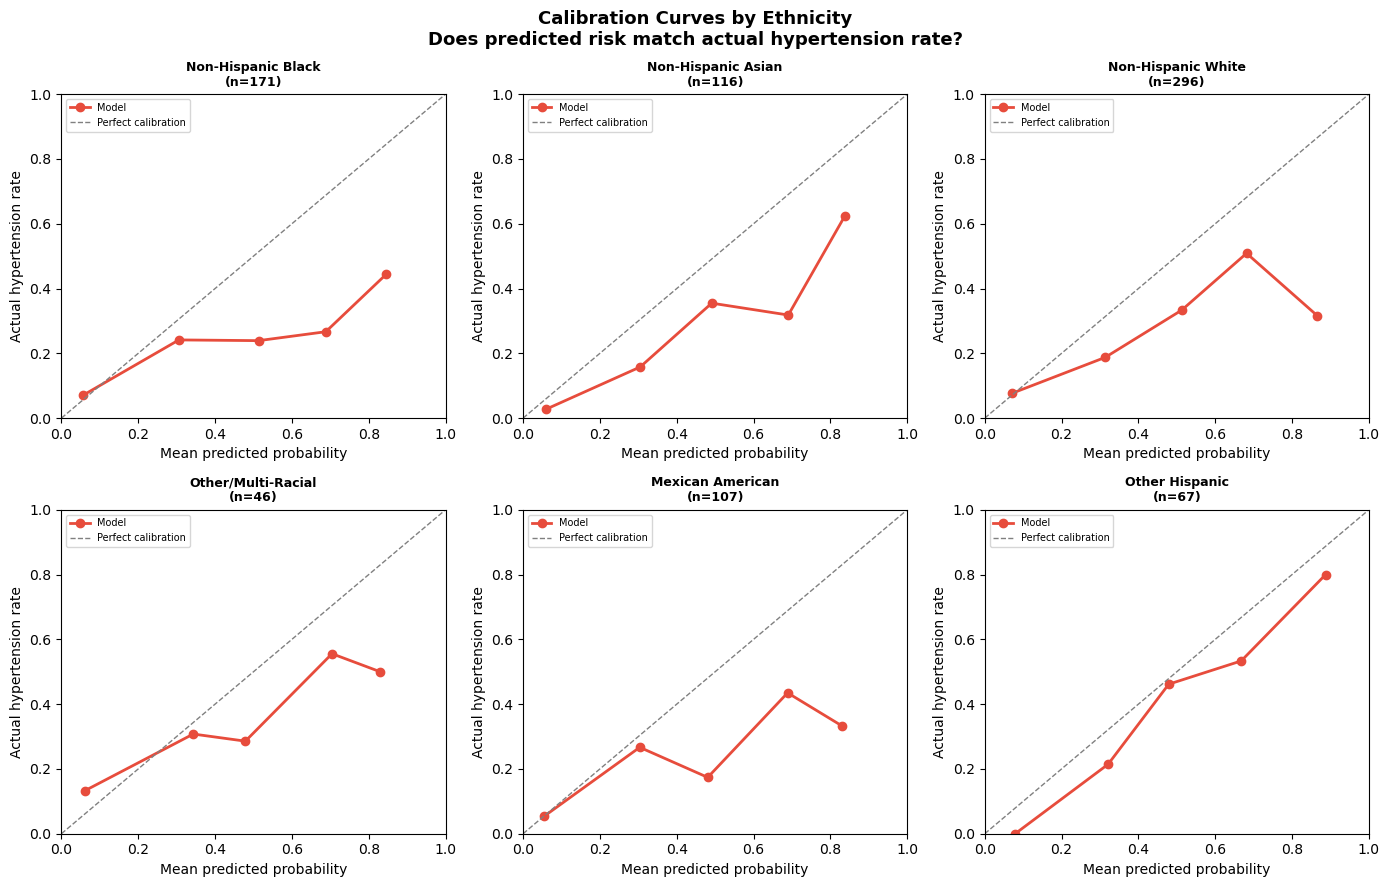

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Calibration Curves by Ethnicity\nDoes predicted risk match actual hypertension rate?', 
             fontsize=13, fontweight='bold')

axes = axes.flatten()
groups = df_test_demo['ethnicity'].unique()

for i, group in enumerate(groups):
    mask = df_test_demo['ethnicity'] == group
    y_sub = y_test[mask]
    y_prob_sub = y_prob[mask]
    
    # calibration curve
    fraction_pos, mean_pred = calibration_curve(y_sub, y_prob_sub, n_bins=5)
    
    axes[i].plot(mean_pred, fraction_pos, marker='o', color='#e74c3c', linewidth=2, label='Model')
    axes[i].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Perfect calibration')
    axes[i].set_title(f'{group}\n(n={mask.sum()})', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Actual hypertension rate')
    axes[i].legend(fontsize=7)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('week9_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

#### Disparate Impact Ratio

In [10]:
# Disparate Impact Ratio
# Reference group = Non-Hispanic White (largest group)
reference_group = 'Non-Hispanic White'
ref_mask = df_test_demo['ethnicity'] == reference_group
ref_positive_rate = y_pred[ref_mask].mean()

dir_results = []

for group in df_test_demo['ethnicity'].unique():
    mask = df_test_demo['ethnicity'] == group
    positive_rate = y_pred[mask].mean()
    dir_value = positive_rate / ref_positive_rate
    
    dir_results.append({
        'group': group,
        'n': mask.sum(),
        'flagged_rate': round(positive_rate, 3),
        'DIR': round(dir_value, 3),
        'passes_4_5ths': dir_value >= 0.8
    })

df_dir = pd.DataFrame(dir_results).sort_values('DIR')
print(df_dir.to_string(index=False))

             group   n  flagged_rate   DIR  passes_4_5ths
  Mexican American 107         0.579 0.917           True
Non-Hispanic Black 171         0.585 0.926           True
Non-Hispanic Asian 116         0.612 0.969           True
    Other Hispanic  67         0.627 0.992           True
Other/Multi-Racial  46         0.630 0.998           True
Non-Hispanic White 296         0.632 1.000           True


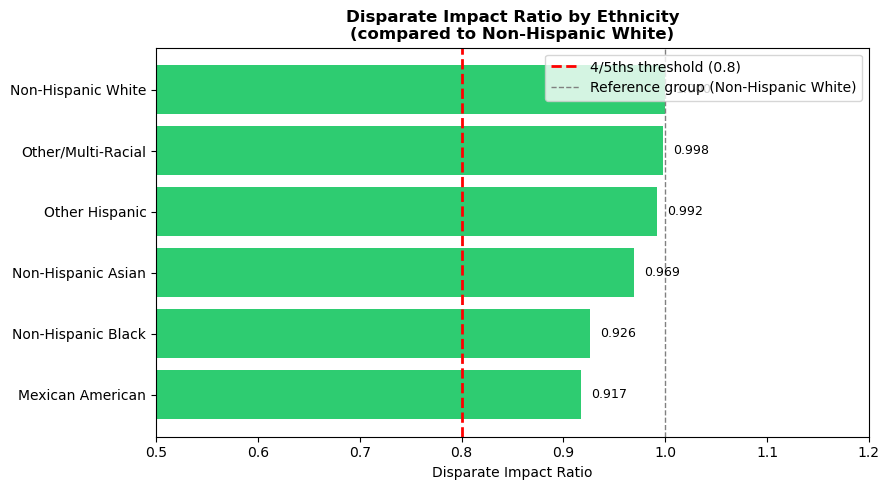

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#2ecc71' if v else '#e74c3c' for v in df_dir['passes_4_5ths']]
bars = ax.barh(df_dir['group'], df_dir['DIR'], color=colors)

ax.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='4/5ths threshold (0.8)')
ax.axvline(x=1.0, color='gray', linestyle='--', linewidth=1, label='Reference group (Non-Hispanic White)')

ax.set_xlabel('Disparate Impact Ratio')
ax.set_title('Disparate Impact Ratio by Ethnicity\n(compared to Non-Hispanic White)', fontweight='bold')
ax.legend()
ax.set_xlim(0.5, 1.2)

for bar, val in zip(bars, df_dir['DIR']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('week9_disparate_impact.png', dpi=150, bbox_inches='tight')
plt.show()

##### The Disparate Impact Ratio measures whether the model flags patients for hypertension at comparable rates across ethnic groups, relative to the reference group of Non-Hispanic White patients. All ethnic groups pass the 4/5ths rule — the lowest DIR is Mexican American at 0.917, well above the 0.8 threshold. On this measure alone, the model appears fair. However, passing DIR does not mean the model is equitable. DIR only checks whether flagging rates are similar — it says nothing about whether the right patients are being flagged within each group. Our equalized odds analysis already showed a 26.5 percentage point TPR gap between Non-Hispanic Black and Other Hispanic patients, and calibration analysis revealed the model doubles actual risk for Black patients at high probability scores. A model can flag groups equally often while still being systematically less accurate for some groups than others. DIR passing should therefore be interpreted cautiously alongside the other fairness metrics.

In [12]:
scorecard_data = {
    'Fairness Criterion': [
        'Equalized Odds (TPR)',
        'Equalized Odds (FPR)', 
        'Calibration',
        'Disparate Impact Ratio'
    ],
    'Non-Hispanic Black': ['❌ FAIL', '❌ FAIL', '❌ FAIL', '✅ PASS'],
    'Non-Hispanic White': ['✅ PASS', '❌ FAIL', '⚠️ MARGINAL', '✅ PASS'],
    'Non-Hispanic Asian': ['✅ PASS', '❌ FAIL', '❌ FAIL', '✅ PASS'],
    'Mexican American':   ['❌ FAIL', '❌ FAIL', '❌ FAIL', '✅ PASS'],
    'Other Hispanic':     ['✅ PASS', '✅ PASS', '✅ PASS', '✅ PASS'],
    'Other/Multi-Racial': ['⚠️ MARGINAL', '❌ FAIL', '⚠️ MARGINAL', '✅ PASS'],
}

df_scorecard = pd.DataFrame(scorecard_data)
print(df_scorecard.to_string(index=False))

    Fairness Criterion Non-Hispanic Black Non-Hispanic White Non-Hispanic Asian Mexican American Other Hispanic Other/Multi-Racial
  Equalized Odds (TPR)             ❌ FAIL             ✅ PASS             ✅ PASS           ❌ FAIL         ✅ PASS        ⚠️ MARGINAL
  Equalized Odds (FPR)             ❌ FAIL             ❌ FAIL             ❌ FAIL           ❌ FAIL         ✅ PASS             ❌ FAIL
           Calibration             ❌ FAIL        ⚠️ MARGINAL             ❌ FAIL           ❌ FAIL         ✅ PASS        ⚠️ MARGINAL
Disparate Impact Ratio             ✅ PASS             ✅ PASS             ✅ PASS           ✅ PASS         ✅ PASS             ✅ PASS


C:\Users\syafi\AppData\Local\Temp\ipykernel_4504\2892735262.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig('week9_fairness_scorecard.png', dpi=150, bbox_inches='tight')
C:\Users\syafi\AppData\Local\Temp\ipykernel_4504\2892735262.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig('week9_fairness_scorecard.png', dpi=150, bbox_inches='tight')
C:\Users\syafi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\syafi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


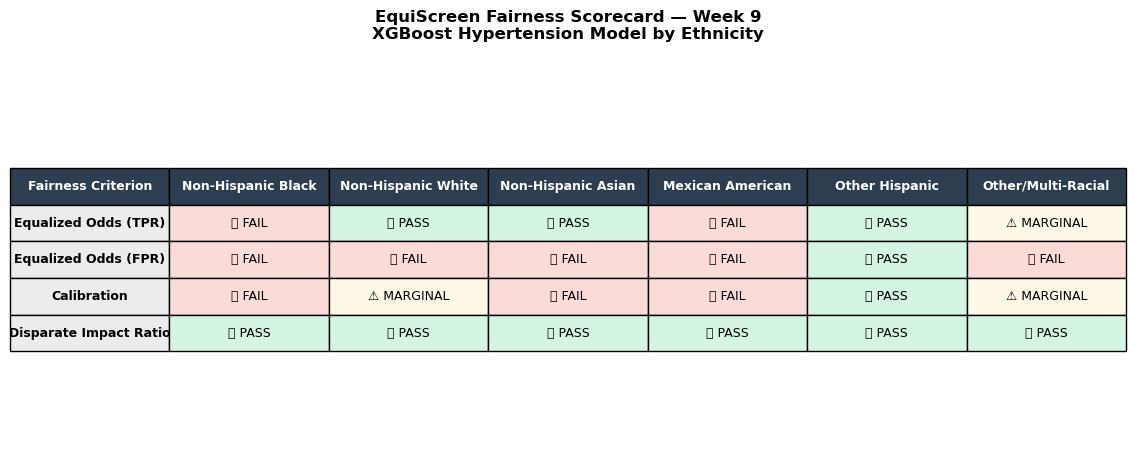

Scorecard saved!


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

table = ax.table(
    cellText=df_scorecard.values,
    colLabels=df_scorecard.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.2)

# Colour the header row
for j in range(len(df_scorecard.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Colour cells based on pass/fail
for i in range(1, len(df_scorecard) + 1):
    for j in range(1, len(df_scorecard.columns)):
        cell_text = df_scorecard.values[i-1][j]
        if 'FAIL' in cell_text:
            table[i, j].set_facecolor('#fadbd8')
        elif 'PASS' in cell_text:
            table[i, j].set_facecolor('#d5f5e3')
        elif 'MARGINAL' in cell_text:
            table[i, j].set_facecolor('#fef9e7')

# Colour criterion column
for i in range(1, len(df_scorecard) + 1):
    table[i, 0].set_facecolor('#eaecee')
    table[i, 0].set_text_props(fontweight='bold')

plt.title('EquiScreen Fairness Scorecard — Week 9\nXGBoost Hypertension Model by Ethnicity', 
          fontweight='bold', fontsize=12, pad=20)

plt.savefig('week9_fairness_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scorecard saved!")

##### In Week 9, three formal fairness frameworks were applied to evaluate the XGBoost hypertension model across ethnic subgroups. The equalized odds analysis revealed a 26.5 percentage point TPR gap between Other Hispanic (1.000) and Non-Hispanic Black (0.735) patients — the core fairness violation, meaning the model misses significantly more actual hypertensive cases in Black patients. The FPR disparity was smaller at 9 percentage points but compounded by a model-wide over-flagging tendency driven by the aggressive 0.3 threshold. Calibration analysis revealed systematic overconfidence across most groups, with the most severe case being Non-Hispanic Black patients — where an 80% predicted probability corresponds to only a 40% actual hypertension rate, effectively doubling true clinical risk. The Disparate Impact Ratio analysis showed all groups passing the 4/5ths rule, appearing fair on the surface. However, this result is misleading — DIR only measures flagging rates, not accuracy. A model can flag groups equally often while failing them very differently in practice, which is exactly what the equalized odds and calibration results confirm.
Taken together, the fairness scorecard identifies Non-Hispanic Black patients as the most consistently underserved group — failing three of four fairness criteria. This is also the group carrying the highest real-world hypertension burden. The audit demonstrates that aggregate model performance metrics mask meaningful demographic disparities, and that no single fairness metric is sufficient — all three frameworks are needed to tell the complete story.
